<a href="https://colab.research.google.com/github/harikautukuru1609/-Advanced-CSS3-Responsive-Architecture/blob/main/dl_project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow pandas numpy scikit-learn matplotlib


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [4]:
np.random.seed(42)

data = {
    "traffic_level": np.random.randint(1, 11, 1000),
    "distance_km": np.random.uniform(0.5, 15, 1000),
    "speed_kmph": np.random.uniform(10, 60, 1000),
    "passengers": np.random.randint(5, 80, 1000),
    "stops_remaining": np.random.randint(1, 15, 1000)
}

df = pd.DataFrame(data)

# Create arrival time in minutes
df["arrival_time"] = (
    (df["distance_km"] / df["speed_kmph"]) * 60
    + df["traffic_level"] * 1.5
    + df["stops_remaining"] * 0.8
    + df["passengers"] * 0.03
)

df.head()

,traffic_level,distance_km,speed_kmph,passengers,stops_remaining,arrival_time
0,7,4.212225,12.391541,22,2,33.155648
1,4,11.028386,11.901092,23,13,72.690203
2,8,9.097962,47.310363,59,14,36.508227
3,5,1.982084,42.951777,30,14,22.368803
4,7,13.821883,50.106528,10,2,28.950996


In [5]:
features = [
    "traffic_level",
    "distance_km",
    "speed_kmph",
    "passengers",
    "stops_remaining"
]

X = df[features]
y = df["arrival_time"]

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (1000, 5)
Output shape: (1000,)


In [6]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [7]:
time_steps = 10

X_sequence = []
y_sequence = []

for i in range(time_steps, len(X_scaled)):
    X_sequence.append(X_scaled[i-time_steps:i])
    y_sequence.append(y_scaled[i])

X_sequence = np.array(X_sequence)
y_sequence = np.array(y_sequence)

print("X shape:", X_sequence.shape)
print("Y shape:", y_sequence.shape)

X shape: (990, 10, 5)
Y shape: (990, 1)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sequence,
    y_sequence,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (792, 10, 5)
Testing data: (198, 10, 5)


In [9]:
model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0548 - mae: 0.1826 - val_loss: 0.0271 - val_mae: 0.1131
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0279 - mae: 0.1257 - val_loss: 0.0258 - val_mae: 0.1286
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0257 - mae: 0.1188 - val_loss: 0.0253 - val_mae: 0.1260
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0241 - mae: 0.1169 - val_loss: 0.0254 - val_mae: 0.1266
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0249 - mae: 0.1188 - val_loss: 0.0250 - val_mae: 0.1242
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0251 - mae: 0.1180 - val_loss: 0.0246 - val_mae: 0.1189
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0248 - mae: 0.1174 - val_loss: 0.0249 - val_mae: 0.1228
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0250 - mae: 0.1183 - val_loss: 0.0257 - val_mae: 0.1276
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0247 - mae:

In [11]:
loss, mae = model.evaluate(X_test, y_test)

print("Test MAE:", mae)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0310 - mae: 0.1275 
Test MAE: 0.12752166390419006


In [12]:
predictions = model.predict(X_test)

predictions_actual = scaler_y.inverse_transform(predictions)
y_test_actual = scaler_y.inverse_transform(y_test)

print("Predicted Arrival Time:")
print(predictions_actual[:10])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted Arrival Time:
[[28.956575]
 [29.316204]
 [28.777658]
 [33.327335]
 [28.802279]
 [34.165104]
 [29.990244]
 [31.605234]
 [28.385002]
 [31.956429]]


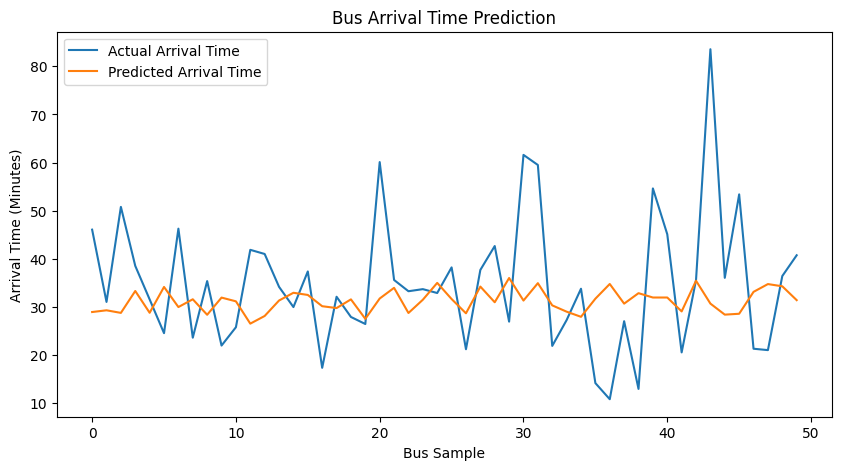

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test_actual[:50],
    label="Actual Arrival Time"
)

plt.plot(
    predictions_actual[:50],
    label="Predicted Arrival Time"
)

plt.title("Bus Arrival Time Prediction")
plt.xlabel("Bus Sample")
plt.ylabel("Arrival Time (Minutes)")

plt.legend()
plt.show()

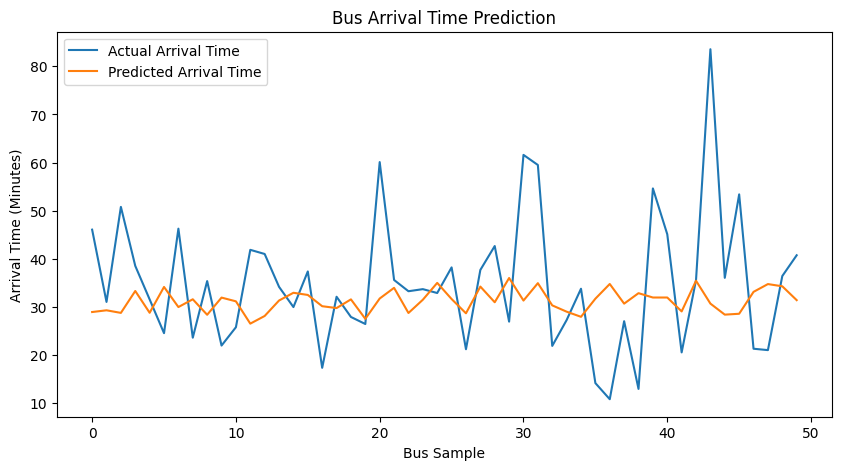

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test_actual[:50],
    label="Actual Arrival Time"
)

plt.plot(
    predictions_actual[:50],
    label="Predicted Arrival Time"
)

plt.title("Bus Arrival Time Prediction")
plt.xlabel("Bus Sample")
plt.ylabel("Arrival Time (Minutes)")

plt.legend()
plt.show()

In [15]:
traffic = float(input("Enter traffic level (1-10): "))
distance = float(input("Enter distance to stop (km): "))
speed = float(input("Enter current bus speed (km/h): "))
passengers = float(input("Enter number of passengers: "))
stops = float(input("Enter stops remaining: "))

new_data = np.array([
    [traffic, distance, speed, passengers, stops]
])

new_scaled = scaler_X.transform(new_data)

# Repeat the current condition for 10 time steps
new_sequence = np.repeat(
    new_scaled.reshape(1, 1, 5),
    time_steps,
    axis=1
)

prediction = model.predict(new_sequence, verbose=0)

arrival_minutes = scaler_y.inverse_transform(prediction)

print(
    "\nPredicted Bus Arrival Time:",
    round(float(arrival_minutes[0][0]), 2),
    "minutes"
)

Enter traffic level (1-10): 5
Enter distance to stop (km): 4
Enter current bus speed (km/h): 30
Enter number of passengers: 40
Enter stops remaining: 30

Predicted Bus Arrival Time: 49.18 minutes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
